# VET Data

**Importing Package**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Sheets**

In [5]:
# Load Excel file
file_path = 'VET_Data_task1.xlsx'
xls = pd.ExcelFile(file_path)
print("Available Sheets:", xls.sheet_names)

Available Sheets: ['Tasks', 'Data Dictionary', 'Organisation', 'Contract', 'Student', 'Enrolment']


In [6]:
# Load individual sheets based on the Data Dictionary
organisation_df = pd.read_excel(xls, sheet_name='Organisation')
contract_df = pd.read_excel(xls, sheet_name='Contract')
student_df = pd.read_excel(xls, sheet_name='Student')
enrolment_df = pd.read_excel(xls, sheet_name='Enrolment')

In [7]:
# Display basic info and first few rows
display(enrolment_df.head(10))

,Student_ID,USI,Provider_ID,RTO_ID,Provider_Name,Funding_Source,Program_ID,Program_Name,Unit_ID,Unit_Name,Nominal_Hours,Outcome,Enrol_Start_Date,Delivery_Year,Location,Remoteness,Industry,AHC_Funded,Funded_Flag
0,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIICCM201E,Carry out basic earthworks,40,40,2024-04-16,2025,Jabiru,Remote,Resources,6,15%_only
1,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIIRIS201E,Conduct local risk control,NaN,51,2024-04-16,2025,Jabiru,Remote,Resources,4,15%_only
2,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIIWHS201E,Work safely and follow WHS,20,70,2024-04-16,2025,Jabiru,Remote,Resources,3,15%_only
3,STU69445,JCS4RGB82E,P005,2003,NaN,11K,CER30115,Certificate III in Early Childhood Education a...,CHCECE005,Provide care for babies,55,30,2025-04-26,2025,Darwin,Urban,Community Services,55,Y
4,STU69445,JCS4RGB82E,P005,2003,Top End Workforce Solutions,11K,CER30115,Certificate III in Early Childhood Education a...,CHCECE002,Ensure the health and safety,40,20,2025-04-26,2025,Darwin,Urban,Community Services,40,Y
5,STU69445,JCS4RGB82E,P005,2003,NaN,11K,CER30115,Certificate III in Early Childhood Education a...,CHCECE003,Provide care for children,50,20,2025-04-26,2025,Darwin,Urban,Community Services,50,Y
6,STU69445,JCS4RGB82E,P005,2003,Top End Workforce Solutions,11K,CER30115,Certificate III in Early Childhood Education a...,CHCECE004,Promote and provide activities,45,30,2025-04-26,2025,Darwin,Urban,Community Services,45,Y
7,STU69445,JCS4RGB82E,P005,2003,Top End Workforce Solutions,11K,CER30115,Certificate III in Early Childhood Education a...,CHCECE001,Develop cultural competence,60,40,2025-04-26,2025,Darwin,Urban,Community Services,60,Y
8,STU79006,UQ3FBSJYCU,P008,1003,Jabiru Community College,FFT,FSK10213,Certificate I in Skills for Vocational Pathways,FSKOCM07,Interact effectively with others,20,81,2025-11-19,2025,Nhulunbuy,Remote,Foundation Skills,20,Y
9,STU79006,UQ3FBSJYCU,P008,1003,Jabiru Community College,FFT,FSK10213,Certificate I in Skills for Vocational Pathways,FSKNUM03,Use whole numbers to complete tasks,25,20,2025-11-19,2025,Nhulunbuy,Remote,Foundation Skills,25,Y


**Data Cleaning**

In [8]:
# Convert all columns to lowercase
enrolment_df.columns = enrolment_df.columns.str.lower()

In [9]:
# Check data types and non-null counts
enrolment_df.info()

# Check for missing values per column
print("\nMissing Values:")
print(enrolment_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5505 entries, 0 to 5504
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   student_id        5505 non-null   object        
 1   usi               5505 non-null   object        
 2   provider_id       5505 non-null   object        
 3   rto_id            5505 non-null   int64         
 4   provider_name     5177 non-null   object        
 5   funding_source    5505 non-null   object        
 6   program_id        5505 non-null   object        
 7   program_name      5505 non-null   object        
 8   unit_id           5505 non-null   object        
 9   unit_name         5505 non-null   object        
 10  nominal_hours     5342 non-null   object        
 11  outcome           5505 non-null   int64         
 12  enrol_start_date  5505 non-null   datetime64[ns]
 13  delivery_year     5505 non-null   int64         
 14  location          5505 n

In [10]:
# Checking duplicates
exact_dupes_count = enrolment_df.duplicated().sum()
print("Exact duplicate rows:", exact_dupes_count)

# Remove duplicates if any exist
if exact_dupes_count > 0:
    enrolment_df = enrolment_df.drop_duplicates().reset_index(drop=True)
    print("Total rows after removing duplicates:", len(enrolment_df))

Exact duplicate rows: 5
Total rows after removing duplicates: 5500


In [11]:
# converting to string, strip whitespace, and make lowercase to catch variations safely
enrolment_df['nominal_hours'] = enrolment_df['nominal_hours'].astype(str).str.strip().str.lower()

# defining the replacement mappings
replacements = {
    'thirty': 30,
    'n/a': 'N/A',
    '-': 'N/A',
    'unknown': 'N/A',
    'nan': 'N/A',   # Handles blank/missing values converted to strings
    'none': 'N/A',
    '': 'N/A'
}

In [12]:
# Applying replacements
enrolment_df['nominal_hours'] = enrolment_df['nominal_hours'].replace(replacements)

# Finally verifying the cleaned unique values and their counts
print("Cleaned 'nominal_hour' Value Counts:")
display(enrolment_df['nominal_hours'].value_counts(dropna=False))

Cleaned 'nominal_hour' Value Counts:


nominal_hours
30     1156
20      799
25      786
40      639
50      469
60      464
35      344
45      313
N/A     201
15      133
55      128
30       46
tbd      22
Name: count, dtype: int64

In [13]:
display(enrolment_df)

,student_id,usi,provider_id,rto_id,provider_name,funding_source,program_id,program_name,unit_id,unit_name,nominal_hours,outcome,enrol_start_date,delivery_year,location,remoteness,industry,ahc_funded,funded_flag
0,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIICCM201E,Carry out basic earthworks,40,40,2024-04-16,2025,Jabiru,Remote,Resources,6,15%_only
1,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIIRIS201E,Conduct local risk control,N/A,51,2024-04-16,2025,Jabiru,Remote,Resources,4,15%_only
2,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIIWHS201E,Work safely and follow WHS,20,70,2024-04-16,2025,Jabiru,Remote,Resources,3,15%_only
3,STU69445,JCS4RGB82E,P005,2003,NaN,11K,CER30115,Certificate III in Early Childhood Education a...,CHCECE005,Provide care for babies,55,30,2025-04-26,2025,Darwin,Urban,Community Services,55,Y
4,STU69445,JCS4RGB82E,P005,2003,Top End Workforce Solutions,11K,CER30115,Certificate III in Early Childhood Education a...,CHCECE002,Ensure the health and safety,40,20,2025-04-26,2025,Darwin,Urban,Community Services,40,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,STU68205,BE4AXSM55L,P004,2002,Barkly Regional Training Services,11K,CER40115,Certificate IV in Early Childhood Education an...,CHCECE016,Establish and maintain a safe environment,45,52,2024-04-24,2024,Darwin,Urban,Community Services,38,85%_only
5496,STU68205,BE4AXSM55L,P004,2002,Barkly Regional Training Services,11K,CER40115,Certificate IV in Early Childhood Education an...,CHCECE014,Effective strategies for inclusion,50,51,2024-04-24,2024,Darwin,Urban,Community Services,42,85%_only
5497,STU68205,BE4AXSM55L,P004,2002,Barkly Regional Training Services,11K,CER40115,Certificate IV in Early Childhood Education an...,CHCECE019,Early childhood education and care,60,30,2024-04-24,2024,Darwin,Urban,Community Services,60,Y
5498,STU75156,ZCN9NG5VUP,P004,2002,Barkly Regional Training Services,11J,AHC20116,Certificate II in Agriculture,AHCWRK201,Communicate in the workplace,20,20,2025-02-03,2025,Alice Springs,Regional,Primary Industry,20,Y


**Exploratory Data Analysis (EDA)**

In [14]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [15]:
print(enrolment_df.columns.tolist())

['student_id', 'usi', 'provider_id', 'rto_id', 'provider_name', 'funding_source', 'program_id', 'program_name', 'unit_id', 'unit_name', 'nominal_hours', 'outcome', 'enrol_start_date', 'delivery_year', 'location', 'remoteness', 'industry', 'ahc_funded', 'funded_flag']


In [16]:
# Convert organisation_df columns to lowercase to match enrolment_df
organisation_df.columns = organisation_df.columns.str.lower()

# Now merge Enrolment with Organisation details using 'provider_id'
merged_df = enrolment_df.merge(organisation_df, on='provider_id', how='left')

print(f"Merged Dataset Shape: {merged_df.shape}")
display(merged_df.head(5))

Merged Dataset Shape: (6864, 23)


,student_id,usi,provider_id,rto_id,provider_name,funding_source,program_id,program_name,unit_id,unit_name,...,delivery_year,location,remoteness,industry,ahc_funded,funded_flag,rto_code,rto_name,organisation_type,region
0,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIICCM201E,Carry out basic earthworks,...,2025,Jabiru,Remote,Resources,6,15%_only,2001,NT Skills & Training Pty Ltd,Private,Alice Springs
1,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIICCM201E,Carry out basic earthworks,...,2025,Jabiru,Remote,Resources,6,15%_only,2001,NT Skills & Training,Private,Alice Springs
2,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIIRIS201E,Conduct local risk control,...,2025,Jabiru,Remote,Resources,4,15%_only,2001,NT Skills & Training Pty Ltd,Private,Alice Springs
3,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIIRIS201E,Conduct local risk control,...,2025,Jabiru,Remote,Resources,4,15%_only,2001,NT Skills & Training,Private,Alice Springs
4,STU45092,BPLYXGRTQA,P003,2001,NT Skills & Training Pty Ltd,11K,RII20715,Certificate II in Resources and Infrastructure,RIIWHS201E,Work safely and follow WHS,...,2025,Jabiru,Remote,Resources,3,15%_only,2001,NT Skills & Training Pty Ltd,Private,Alice Springs


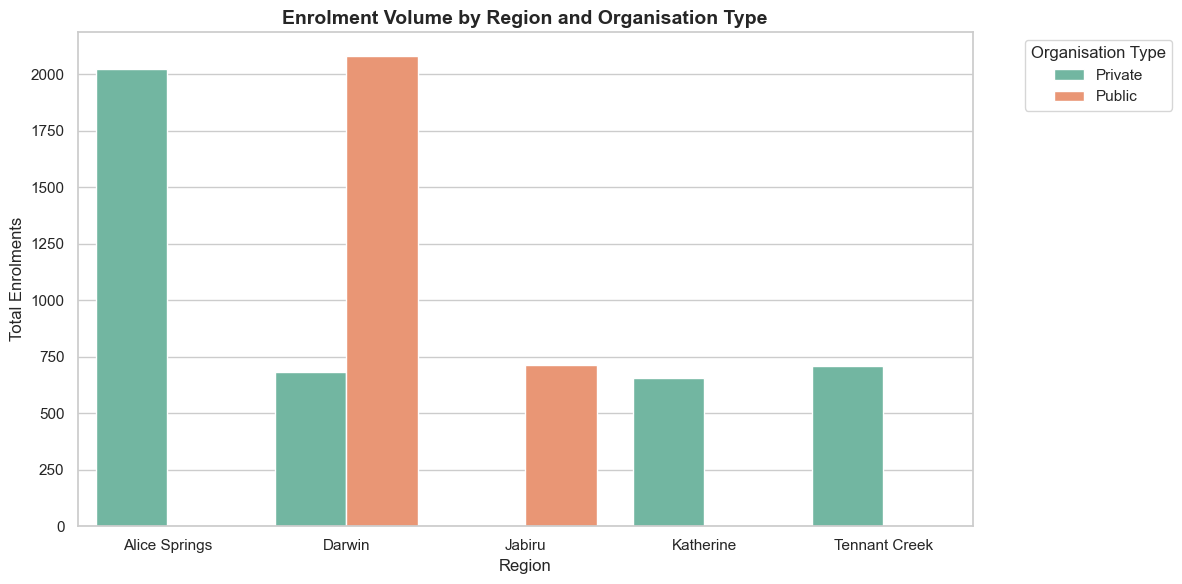

In [17]:
# 1. Group by Region and Organisation Type to count total enrolments
region_org_summary = merged_df.groupby(['region', 'organisation_type'])['provider_id'].count().reset_index()
region_org_summary.rename(columns={'provider_id': 'enrolment_count'}, inplace=True)

# 2. Plot Enrolments by Region broken down by Organisation Type
plt.figure(figsize=(12, 6))
sns.barplot(
    data=region_org_summary,
    x='region',
    y='enrolment_count',
    hue='organisation_type',
    palette='Set2'
)

plt.title('Enrolment Volume by Region and Organisation Type', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Enrolments', fontsize=12)
plt.legend(title='Organisation Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

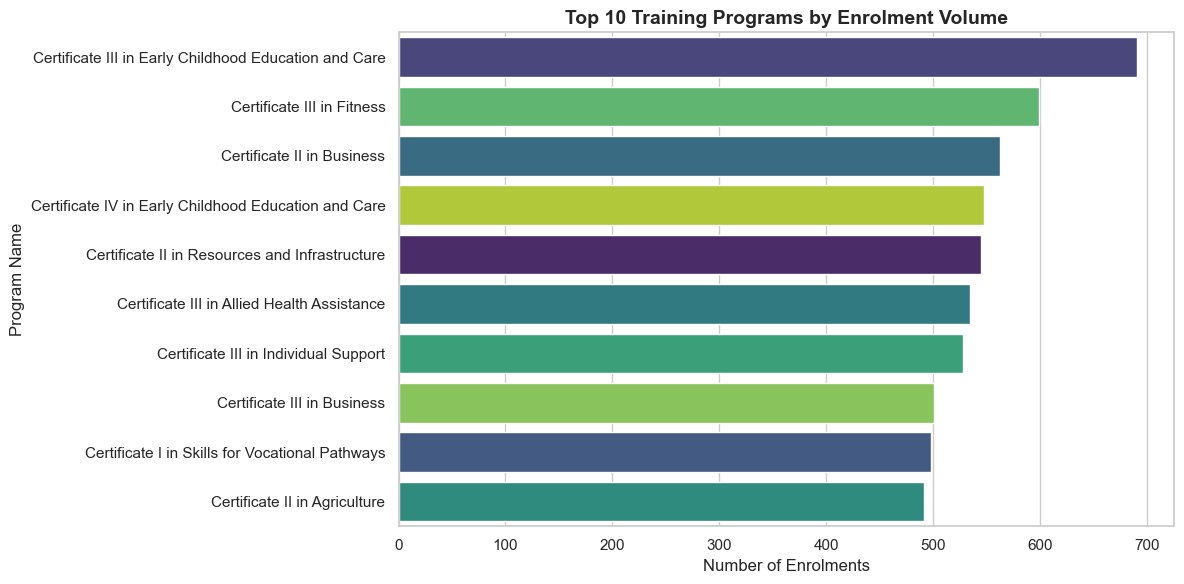

In [20]:
plt.figure(figsize=(12, 6))
top_programs = enrolment_df['program_name'].value_counts().nlargest(10).index

sns.countplot(
    data=enrolment_df[enrolment_df['program_name'].isin(top_programs)],
    y='program_name',
    hue='program_name',
    legend=False,
    order=top_programs,
    palette='viridis'
)

plt.title('Top 10 Training Programs by Enrolment Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Enrolments', fontsize=12)
plt.ylabel('Program Name', fontsize=12)
plt.tight_layout()
plt.show()

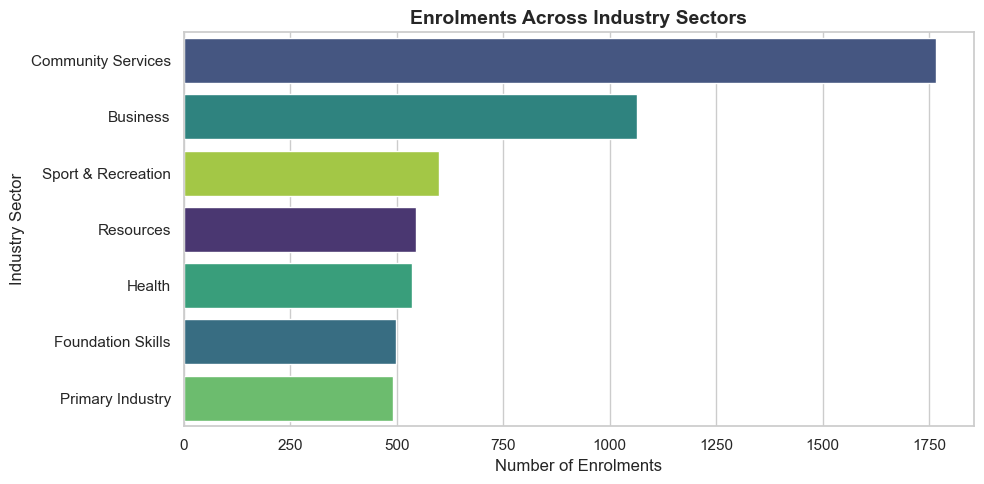

In [32]:
plt.figure(figsize=(10, 5))
industry_order = enrolment_df['industry'].value_counts().index

sns.countplot(
    data=enrolment_df,
    y='industry',
    hue='industry',
    legend=False,
    order=industry_order,
    palette='viridis'  # Try changing this to 'magma', 'plasma', 'rocket', or 'Spectral'
)

plt.title('Enrolments Across Industry Sectors', fontsize=14, fontweight='bold')
plt.xlabel('Number of Enrolments', fontsize=12)
plt.ylabel('Industry Sector', fontsize=12)
plt.tight_layout()
plt.show()

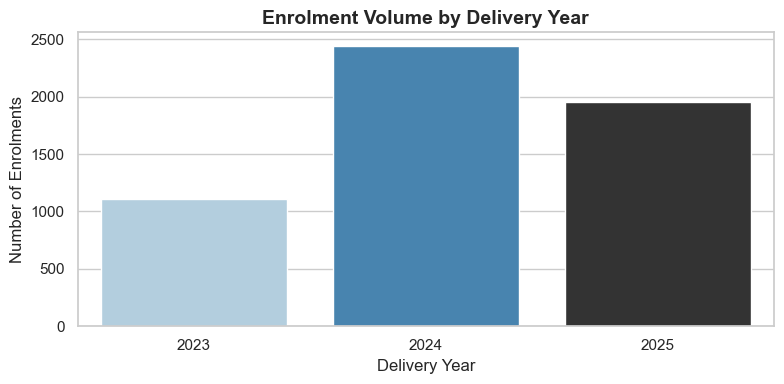

In [26]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=enrolment_df,
    x='delivery_year',
    hue='delivery_year',
    legend=False,
    palette='Blues_d'
)

plt.title('Enrolment Volume by Delivery Year', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Year', fontsize=12)
plt.ylabel('Number of Enrolments', fontsize=12)
plt.tight_layout()
plt.show()

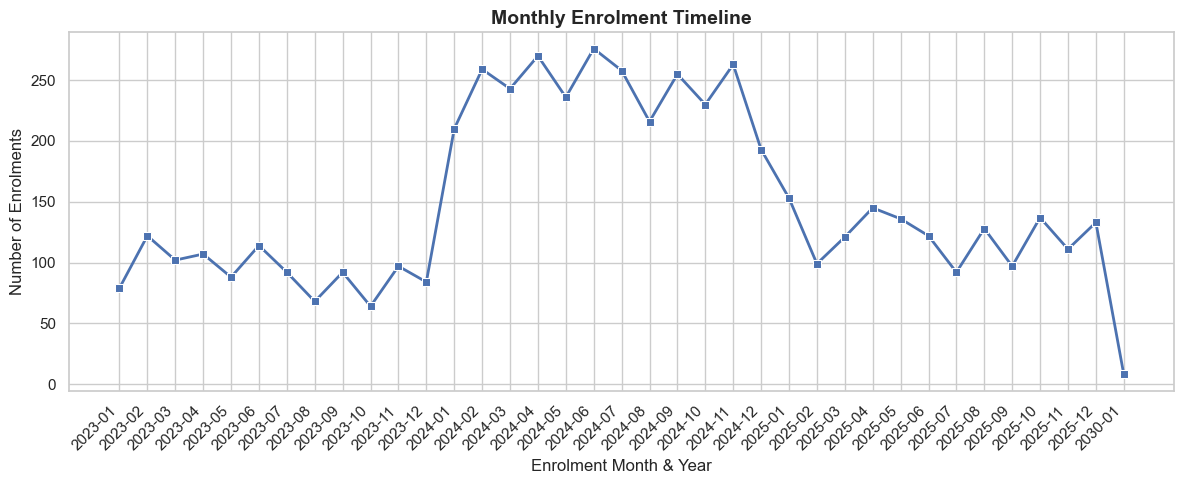

In [31]:
# Convert start date to datetime and extract year-month period
enrolment_df['enrol_start_date'] = pd.to_datetime(enrolment_df['enrol_start_date'], errors='coerce')
enrolment_df['enrol_month_year'] = enrolment_df['enrol_start_date'].dt.to_period('M').astype(str)

# Group by month-year
monthly_trend = enrolment_df.groupby('enrol_month_year').size().reset_index(name='enrolment_count')

# Plot line chart
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_trend,
    x='enrol_month_year',
    y='enrolment_count',
    marker='s',
    color='b',
    linewidth=2,
    markersize=6
)

plt.title('Monthly Enrolment Timeline', fontsize=14, fontweight='bold')
plt.xlabel('Enrolment Month & Year', fontsize=12)
plt.ylabel('Number of Enrolments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

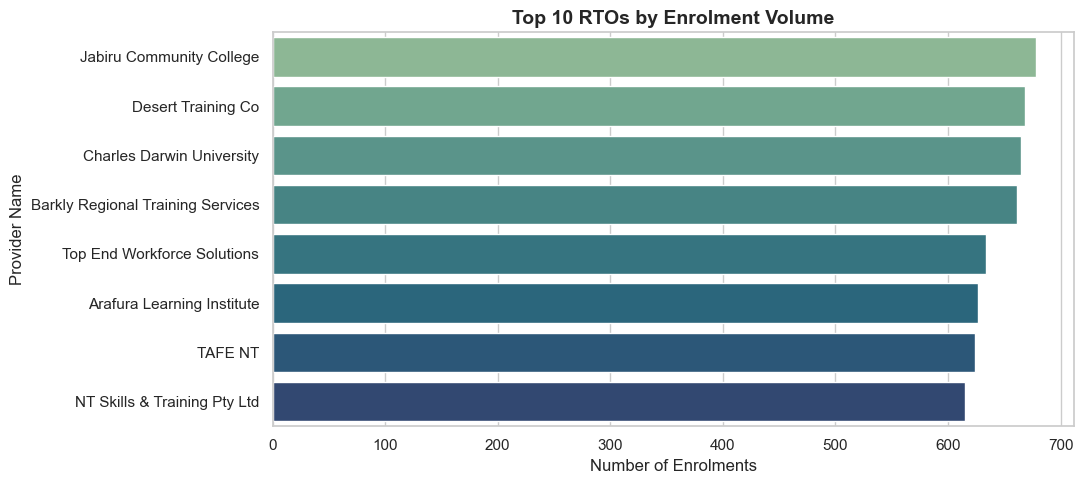

In [34]:
# Calculate top 10 providers by enrolment count
top_providers = enrolment_df['provider_name'].value_counts().nlargest(10).reset_index()
top_providers.columns = ['provider_name', 'enrolment_count']

# Plot top providers
plt.figure(figsize=(11, 5))
sns.barplot(
    data=top_providers,
    x='enrolment_count',
    y='provider_name',
    hue='provider_name',
    legend=False,
    palette='crest'
)
plt.title('Top 10 RTOs by Enrolment Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Enrolments', fontsize=12)
plt.ylabel('Provider Name', fontsize=12)
plt.tight_layout()
plt.show()

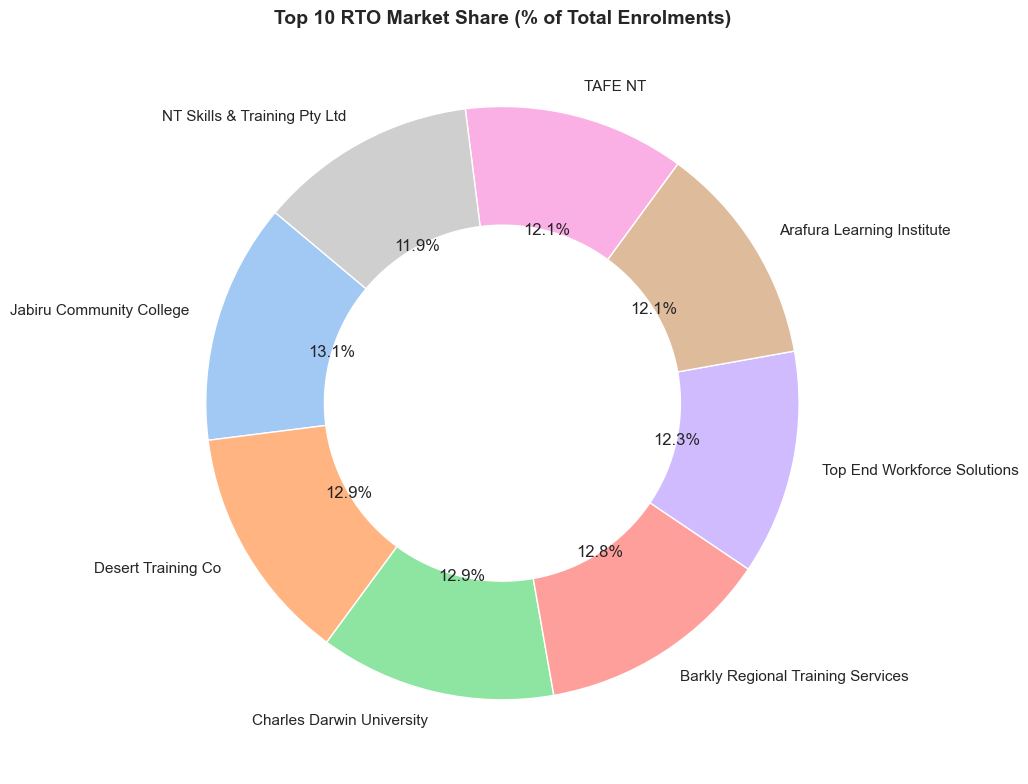

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate top 10 providers and their percentage share
top_providers = enrolment_df['provider_name'].value_counts().nlargest(10).reset_index()
top_providers.columns = ['provider_name', 'enrolment_count']

# Calculate percentage relative to the total enrolment dataset
total_enrolments = len(enrolment_df)
top_providers['percentage'] = (top_providers['enrolment_count'] / total_enrolments) * 100

# 2. Plot as a Donut Chart
plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel', 10)

plt.pie(
    top_providers['percentage'], 
    labels=top_providers['provider_name'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white')  # width=0.4 creates the donut hole
)

plt.title('Top 10 RTO Market Share (% of Total Enrolments)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()